# Импорт необходимых библиотек

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

# Датасеты / трансформации
import torchvision
from torchvision import transforms

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.10.0
torchvision: 0.25.0


In [2]:
import os
import math
import time
import random
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import torch
import torch.nn as nn

import matplotlib.pyplot as plt

import pandas as pd

# -----------------------
# Воспроизводимость
# -----------------------
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# -----------------------
# Устройство
# -----------------------
if torch.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print("Device:", DEVICE)

Device: mps


In [3]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    # Accuracy для классификации: logits -> argmax -> сравнение с y_true.
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def plot_history(history: dict, title: str = "") -> None:
    # history ожидается вида:
    # {
    #   "train_loss": [...], "val_loss": [...],
    #   "train_acc": [...],  "val_acc": [...]
    # }
    epochs = np.arange(1, len(history["train_loss"]) + 1)


    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

In [4]:
import os


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),  # mean/std для 1 канала
])

# Скачиваем датасет
train_full = torchvision.datasets.EMNIST(split="balanced",
    root="./data", train=True, download=True, transform=transform
)
test_ds = torchvision.datasets.EMNIST(split="balanced",
    root="./data", train=False, download=True, transform=transform
)

class_names = train_full.classes
print("classes:", class_names)
print("train size:", len(train_full))
print("test size:", len(test_ds))

classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']
train size: 112800
test size: 18800


In [5]:
BATCH_SIZE = 256 if DEVICE.type in ["cuda", "mps"] else 64

# На Windows в Jupyter иногда бывают проблемы с multiprocessing в DataLoader.
# Поэтому автоматически ставим num_workers=0 на Windows, иначе 2.
NUM_WORKERS = 0 if os.name == "nt" else 2

# train/val split
val_ratio = 0.2
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE.type in ["cuda", "mps"])
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE.type in ["cuda", "mps"])
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE.type in ["cuda", "mps"])
)

# Быстрый sanity-check
x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)

/Users/hkvge/vscode/neuro_2/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


x_batch: torch.Size([256, 1, 28, 28]) torch.float32
y_batch: torch.Size([256]) torch.int64


# 2.3

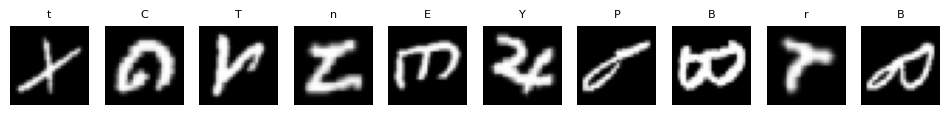

In [6]:
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n]
    y = y[:n]

    plt.figure(figsize=(12, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        # Обратно денормализуем для отображения
        img = x[i].squeeze().numpy()
        img = img * 0.5 + 0.5
        plt.imshow(img, cmap="gray")
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

show_images(train_loader, n=10)

# 2.3.3

In [7]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28 * 28,
        hidden_dims: tuple = (256, 128),
        num_classes: int = 10,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Быстрый sanity-check по форме
model = MLP(dropout_p=0.2, use_batchnorm=True).to(DEVICE)
with torch.no_grad():
    out = model(x_batch.to(DEVICE))
print("logits:", out.shape)

logits: torch.Size([256, 10])


In [8]:
def set_seed(seed: int = 42) -> None:
    # Фиксируем seed для воспроизводимости (насколько это возможно).
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Более детерминированное поведение (может чуть замедлить).
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(42)
baseline = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=False, num_classes=len(class_names)).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=1e-3)

In [9]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()  # включаем train-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()  # включаем eval-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [10]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

# E1

epoch 01/20 | train loss=1.4925, acc=0.5834 | val loss=1.0064, acc=0.7024
epoch 02/20 | train loss=0.8433, acc=0.7440 | val loss=0.7485, acc=0.7740
epoch 03/20 | train loss=0.6679, acc=0.7885 | val loss=0.6718, acc=0.7921
epoch 04/20 | train loss=0.5825, acc=0.8112 | val loss=0.5979, acc=0.8103
epoch 05/20 | train loss=0.5288, acc=0.8260 | val loss=0.5832, acc=0.8103
epoch 06/20 | train loss=0.4914, acc=0.8354 | val loss=0.5463, acc=0.8227
epoch 07/20 | train loss=0.4660, acc=0.8408 | val loss=0.5330, acc=0.8298
epoch 08/20 | train loss=0.4391, acc=0.8489 | val loss=0.5246, acc=0.8294
epoch 09/20 | train loss=0.4182, acc=0.8543 | val loss=0.5138, acc=0.8316
epoch 10/20 | train loss=0.4038, acc=0.8577 | val loss=0.5167, acc=0.8332
epoch 11/20 | train loss=0.3832, acc=0.8653 | val loss=0.5113, acc=0.8366
epoch 12/20 | train loss=0.3738, acc=0.8660 | val loss=0.5052, acc=0.8347
epoch 13/20 | train loss=0.3598, acc=0.8704 | val loss=0.5092, acc=0.8383
epoch 14/20 | train loss=0.3446, acc=0

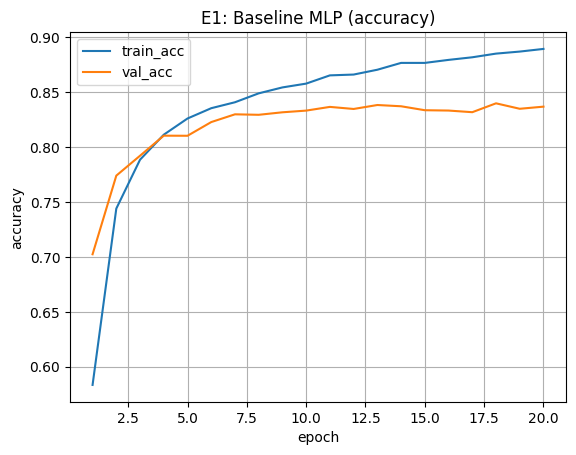

In [11]:
set_seed(42)
model_e1 = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=False,
               num_classes=len(class_names)).to(DEVICE)
optimizer_e1 = optim.Adam(model_e1.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

history_e1 = fit(
    model_e1, train_loader, val_loader,
    optimizer_e1, criterion, DEVICE,
    epochs=20, early_stopping=None
)

best_val_acc_e1 = max(history_e1["val_acc"])
print(f"E1 best_val_acc = {best_val_acc_e1:.4f}")
plot_history(history_e1, title="E1: Baseline MLP")

# E2

epoch 01/20 | train loss=1.6996, acc=0.5171 | val loss=0.9676, acc=0.7153
epoch 02/20 | train loss=1.0101, acc=0.6931 | val loss=0.7503, acc=0.7684
epoch 03/20 | train loss=0.8569, acc=0.7329 | val loss=0.6789, acc=0.7854
epoch 04/20 | train loss=0.7763, acc=0.7557 | val loss=0.6199, acc=0.8039
epoch 05/20 | train loss=0.7269, acc=0.7681 | val loss=0.5924, acc=0.8115
epoch 06/20 | train loss=0.6909, acc=0.7785 | val loss=0.5646, acc=0.8155
epoch 07/20 | train loss=0.6656, acc=0.7830 | val loss=0.5552, acc=0.8213
epoch 08/20 | train loss=0.6436, acc=0.7899 | val loss=0.5373, acc=0.8246
epoch 09/20 | train loss=0.6264, acc=0.7936 | val loss=0.5218, acc=0.8274
epoch 10/20 | train loss=0.6129, acc=0.7973 | val loss=0.5125, acc=0.8319
epoch 11/20 | train loss=0.6026, acc=0.8004 | val loss=0.5038, acc=0.8328
epoch 12/20 | train loss=0.5885, acc=0.8032 | val loss=0.5044, acc=0.8329
epoch 13/20 | train loss=0.5779, acc=0.8049 | val loss=0.4978, acc=0.8345
epoch 14/20 | train loss=0.5692, acc=0

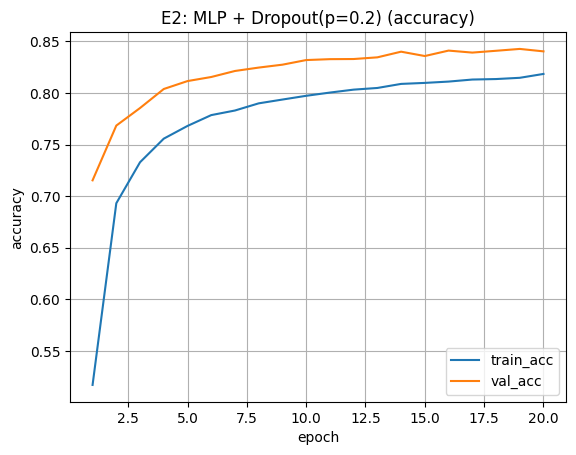

In [12]:
set_seed(42)
model_e2 = MLP(hidden_dims=(256, 128), dropout_p=0.2, use_batchnorm=False,
               num_classes=len(class_names)).to(DEVICE)
optimizer_e2 = optim.Adam(model_e2.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

history_e2 = fit(
    model_e2, train_loader, val_loader,
    optimizer_e2, criterion, DEVICE,
    epochs=20, early_stopping=None
)

best_val_acc_e2 = max(history_e2["val_acc"])
print(f"E2 best_val_acc = {best_val_acc_e2:.4f}")
plot_history(history_e2, title="E2: MLP + Dropout(p=0.2)")

# E3

epoch 01/20 | train loss=1.1458, acc=0.7090 | val loss=0.6639, acc=0.7954
epoch 02/20 | train loss=0.5501, acc=0.8227 | val loss=0.5421, acc=0.8228
epoch 03/20 | train loss=0.4549, acc=0.8467 | val loss=0.4992, acc=0.8364
epoch 04/20 | train loss=0.4017, acc=0.8622 | val loss=0.4825, acc=0.8388
epoch 05/20 | train loss=0.3666, acc=0.8718 | val loss=0.4913, acc=0.8333
epoch 06/20 | train loss=0.3362, acc=0.8803 | val loss=0.4745, acc=0.8416
epoch 07/20 | train loss=0.3163, acc=0.8853 | val loss=0.4691, acc=0.8477
epoch 08/20 | train loss=0.2948, acc=0.8919 | val loss=0.4779, acc=0.8416
epoch 09/20 | train loss=0.2793, acc=0.8962 | val loss=0.4782, acc=0.8447
epoch 10/20 | train loss=0.2634, acc=0.9010 | val loss=0.4912, acc=0.8434
epoch 11/20 | train loss=0.2524, acc=0.9037 | val loss=0.4819, acc=0.8454
epoch 12/20 | train loss=0.2372, acc=0.9092 | val loss=0.5034, acc=0.8409
epoch 13/20 | train loss=0.2272, acc=0.9121 | val loss=0.5148, acc=0.8418
epoch 14/20 | train loss=0.2182, acc=0

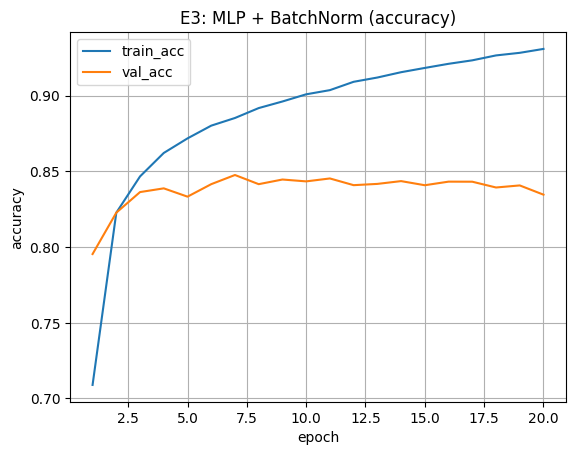

In [13]:
set_seed(42)
model_e3 = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True,
               num_classes=len(class_names)).to(DEVICE)
optimizer_e3 = optim.Adam(model_e3.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

history_e3 = fit(
    model_e3, train_loader, val_loader,
    optimizer_e3, criterion, DEVICE,
    epochs=20, early_stopping=None
)

best_val_acc_e3 = max(history_e3["val_acc"])
print(f"E3 best_val_acc = {best_val_acc_e3:.4f}")
plot_history(history_e3, title="E3: MLP + BatchNorm")

In [14]:
# === Выбор лучшей архитектуры для E4 ===
print(f"E2 (Dropout p=0.2):  best_val_acc = {best_val_acc_e2:.4f}")
print(f"E3 (BatchNorm):       best_val_acc = {best_val_acc_e3:.4f}")
print()
if best_val_acc_e3 >= best_val_acc_e2:
    best_reg = "BatchNorm"
    use_bn_e4, dropout_e4 = True, 0.0
    print(f"Победитель: E3 (BatchNorm), val_acc={best_val_acc_e3:.4f} "
          f">= E2 val_acc={best_val_acc_e2:.4f}")
    print("→ Для E4 берём архитектуру E3: BatchNorm, без Dropout")
else:
    best_reg = "Dropout"
    use_bn_e4, dropout_e4 = False, 0.2
    print(f"Победитель: E2 (Dropout), val_acc={best_val_acc_e2:.4f} "
          f"> E3 val_acc={best_val_acc_e3:.4f}")
    print("→ Для E4 берём архитектуру E2: Dropout(p=0.2), без BatchNorm")

E2 (Dropout p=0.2):  best_val_acc = 0.8427
E3 (BatchNorm):       best_val_acc = 0.8477

Победитель: E3 (BatchNorm), val_acc=0.8477 >= E2 val_acc=0.8427
→ Для E4 берём архитектуру E3: BatchNorm, без Dropout


# E4

In [15]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


epoch 01/20 | train loss=1.1458, acc=0.7090 | val loss=0.6639, acc=0.7954
epoch 02/20 | train loss=0.5501, acc=0.8227 | val loss=0.5421, acc=0.8228
epoch 03/20 | train loss=0.4549, acc=0.8467 | val loss=0.4992, acc=0.8364
epoch 04/20 | train loss=0.4017, acc=0.8622 | val loss=0.4825, acc=0.8388
epoch 05/20 | train loss=0.3666, acc=0.8718 | val loss=0.4913, acc=0.8333
epoch 06/20 | train loss=0.3362, acc=0.8803 | val loss=0.4745, acc=0.8416
epoch 07/20 | train loss=0.3163, acc=0.8853 | val loss=0.4691, acc=0.8477
epoch 08/20 | train loss=0.2948, acc=0.8919 | val loss=0.4779, acc=0.8416
epoch 09/20 | train loss=0.2793, acc=0.8962 | val loss=0.4782, acc=0.8447
epoch 10/20 | train loss=0.2634, acc=0.9010 | val loss=0.4912, acc=0.8434
epoch 11/20 | train loss=0.2524, acc=0.9037 | val loss=0.4819, acc=0.8454
epoch 12/20 | train loss=0.2372, acc=0.9092 | val loss=0.5034, acc=0.8409
EarlyStopping: остановка на эпохе 12. Лучший val_acc=0.8477
E4 best_val_acc = 0.8477  
E4 best_val_acc = 0.8477 

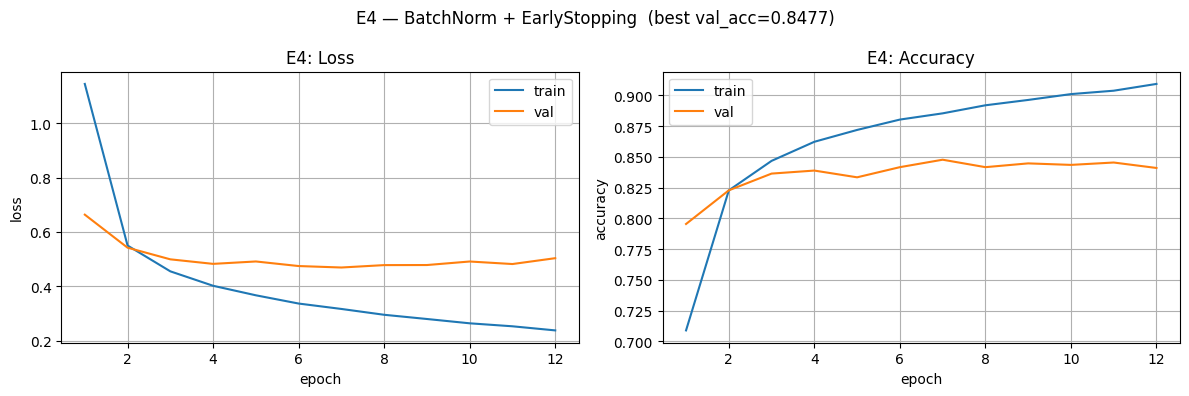

Saved → artifacts/figures/curves_best.png


In [16]:
set_seed(42)
model_e4 = MLP(hidden_dims=(256, 128), dropout_p=dropout_e4, use_batchnorm=use_bn_e4,
               num_classes=len(class_names)).to(DEVICE)
optimizer_e4 = optim.Adam(model_e4.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
es_e4 = EarlyStopping(patience=5)

history_e4 = fit(
    model_e4, train_loader, val_loader,
    optimizer_e4, criterion, DEVICE,
    epochs=20, early_stopping=es_e4
)

best_val_acc_e4 = es_e4.best_score
print(f"E4 best_val_acc = {best_val_acc_e4:.4f}  ")
n_ep_e4 = len(history_e4["val_acc"])
print(f"E4 best_val_acc = {best_val_acc_e4:.4f}  (остановлено на эпохе {n_ep_e4})")

# Сохраняем кривые E4
os.makedirs("artifacts/figures", exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, len(history_e4["train_loss"]) + 1)
axes[0].plot(ep, history_e4["train_loss"], label="train")
axes[0].plot(ep, history_e4["val_loss"], label="val")
axes[0].set_title("E4: Loss")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss")
axes[0].legend(); axes[0].grid(True)
axes[1].plot(ep, history_e4["train_acc"], label="train")
axes[1].plot(ep, history_e4["val_acc"], label="val")
axes[1].set_title("E4: Accuracy")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy")
axes[1].legend(); axes[1].grid(True)
plt.suptitle(f"E4 — {best_reg} + EarlyStopping  (best val_acc={best_val_acc_e4:.4f})")
plt.tight_layout()
plt.savefig("artifacts/figures/curves_best.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → artifacts/figures/curves_best.png")

In [17]:
import json as _json

os.makedirs("artifacts", exist_ok=True)

# Лучшая модель
save_path = "artifacts/best_model.pt"
torch.save(model_e4.state_dict(), save_path)
print(f"Saved model  → {save_path}")

# Конфиг
best_config = {
    "experiment_id": "E4",
    "dataset": "EMNIST-balanced",
    "seed": RANDOM_STATE,
    "hidden_dims": [256, 128],
    "num_classes": len(class_names),
    "activation": "relu",
    "use_batchnorm": use_bn_e4,
    "dropout_p": dropout_e4,
    "optimizer": "Adam",
    "lr": 1e-3,
    "weight_decay": 0,
    "early_stopping_patience": 5,
    "best_val_accuracy": round(float(best_val_acc_e4), 4),
    "regularization": best_reg,
}
with open("artifacts/best_config.json", "w", encoding="utf-8") as _f:
    _json.dump(best_config, _f, indent=2, ensure_ascii=False)
print("Saved config → artifacts/best_config.json")

Saved model  → artifacts/best_model.pt
Saved config → artifacts/best_config.json


# Часть B

## E1
Большой LR

epoch 01/8 | train loss=4.1484, acc=0.0379 | val loss=3.7460, acc=0.0387
epoch 02/8 | train loss=3.6277, acc=0.0492 | val loss=3.6140, acc=0.0574
epoch 03/8 | train loss=3.3445, acc=0.0734 | val loss=3.4605, acc=0.0683
epoch 04/8 | train loss=3.2574, acc=0.0790 | val loss=3.1360, acc=0.0891
epoch 05/8 | train loss=3.1578, acc=0.0883 | val loss=3.0905, acc=0.1126
epoch 06/8 | train loss=3.1735, acc=0.0878 | val loss=3.1169, acc=0.0874
epoch 07/8 | train loss=3.1419, acc=0.0893 | val loss=3.1725, acc=0.0811
epoch 08/8 | train loss=3.1016, acc=0.0915 | val loss=3.2122, acc=0.0829
O1 best_val_acc = 0.1126  ← ожидаемо плохо


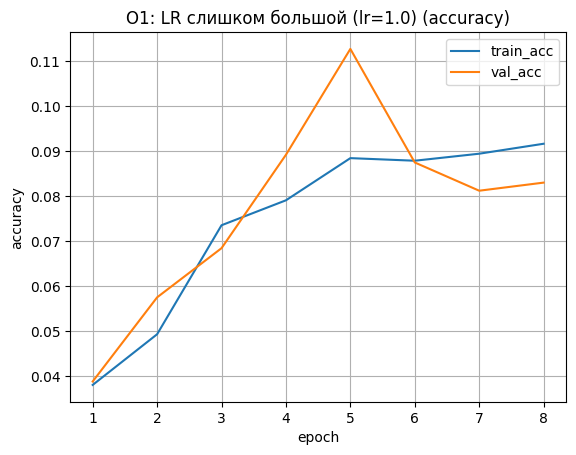

In [18]:
# O1: LR слишком большой
set_seed(42)
model_o1 = MLP(hidden_dims=(256, 128), dropout_p=dropout_e4, use_batchnorm=use_bn_e4,
               num_classes=len(class_names)).to(DEVICE)
optimizer_o1 = optim.Adam(model_o1.parameters(), lr=1.0)  # намеренно огромный
criterion = nn.CrossEntropyLoss()

history_o1 = fit(
    model_o1, train_loader, val_loader,
    optimizer_o1, criterion, DEVICE,
    epochs=8, early_stopping=EarlyStopping(patience=5)
)

best_val_acc_o1 = max(history_o1["val_acc"])
print(f"O1 best_val_acc = {best_val_acc_o1:.4f}  ← ожидаемо плохо")
plot_history(history_o1, title="O1: LR слишком большой (lr=1.0)")

## E2
слишком маленький

epoch 01/8 | train loss=3.9435, acc=0.0219 | val loss=3.9433, acc=0.0223
epoch 02/8 | train loss=3.9435, acc=0.0218 | val loss=3.9439, acc=0.0214
epoch 03/8 | train loss=3.9434, acc=0.0219 | val loss=3.9440, acc=0.0220
epoch 04/8 | train loss=3.9437, acc=0.0216 | val loss=3.9420, acc=0.0224
epoch 05/8 | train loss=3.9437, acc=0.0217 | val loss=3.9440, acc=0.0220
epoch 06/8 | train loss=3.9433, acc=0.0219 | val loss=3.9431, acc=0.0220
epoch 07/8 | train loss=3.9439, acc=0.0219 | val loss=3.9439, acc=0.0224
epoch 08/8 | train loss=3.9437, acc=0.0219 | val loss=3.9429, acc=0.0221
O2 best_val_acc = 0.0224  ← ожидаемо почти случайно


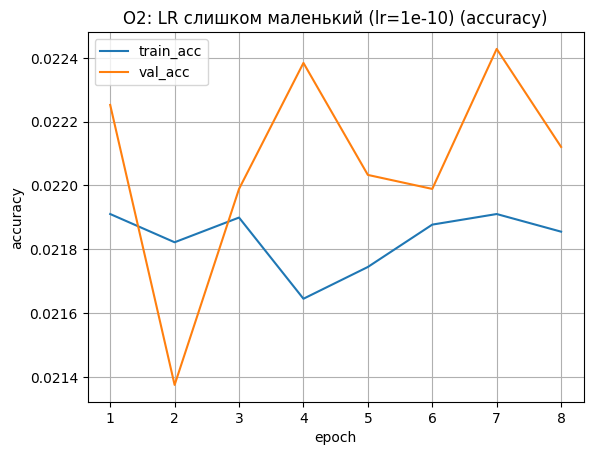

In [19]:
# O2: LR слишком маленький
set_seed(42)
model_o2 = MLP(hidden_dims=(256, 128), dropout_p=dropout_e4, use_batchnorm=use_bn_e4,
               num_classes=len(class_names)).to(DEVICE)
optimizer_o2 = optim.Adam(model_o2.parameters(), lr=1e-10)  # намеренно ничтожный
criterion = nn.CrossEntropyLoss()

history_o2 = fit(
    model_o2, train_loader, val_loader,
    optimizer_o2, criterion, DEVICE,
    epochs=8, early_stopping=EarlyStopping(patience=5)
)

best_val_acc_o2 = max(history_o2["val_acc"])
print(f"O2 best_val_acc = {best_val_acc_o2:.4f}  ← ожидаемо почти случайно")
plot_history(history_o2, title="O2: LR слишком маленький (lr=1e-10)")

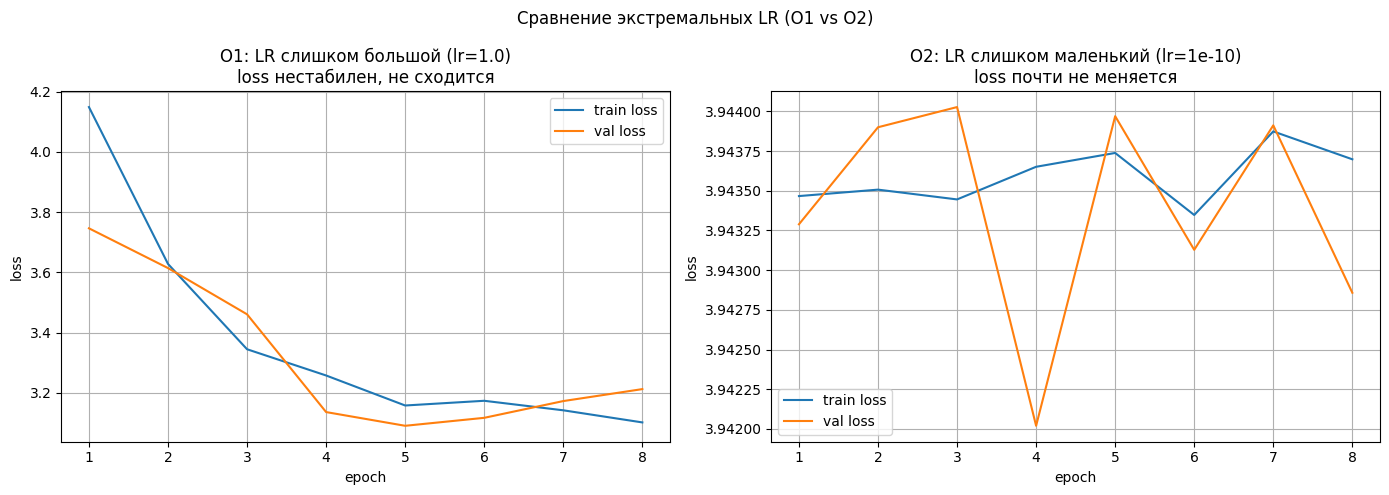

Saved → artifacts/figures/curves_lr_extremes.png


In [20]:
# График O1 vs O2 — демонстрация "плохого" LR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep_o1 = range(1, len(history_o1["val_loss"]) + 1)
ep_o2 = range(1, len(history_o2["val_loss"]) + 1)

axes[0].plot(ep_o1, history_o1["train_loss"], label="train loss")
axes[0].plot(ep_o1, history_o1["val_loss"],   label="val loss")
axes[0].set_title("O1: LR слишком большой (lr=1.0)\nloss нестабилен, не сходится")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(ep_o2, history_o2["train_loss"], label="train loss")
axes[1].plot(ep_o2, history_o2["val_loss"],   label="val loss")
axes[1].set_title("O2: LR слишком маленький (lr=1e-10)\nloss почти не меняется")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("loss")
axes[1].legend(); axes[1].grid(True)

plt.suptitle("Сравнение экстремальных LR (O1 vs O2)")
plt.tight_layout()
plt.savefig("artifacts/figures/curves_lr_extremes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → artifacts/figures/curves_lr_extremes.png")

# E3

epoch 01/15 | train loss=1.4717, acc=0.6415 | val loss=0.8020, acc=0.7677
epoch 02/15 | train loss=0.6743, acc=0.7961 | val loss=0.6218, acc=0.8067
epoch 03/15 | train loss=0.5408, acc=0.8282 | val loss=0.5511, acc=0.8272
epoch 04/15 | train loss=0.4745, acc=0.8445 | val loss=0.5254, acc=0.8305
epoch 05/15 | train loss=0.4312, acc=0.8572 | val loss=0.5069, acc=0.8326
epoch 06/15 | train loss=0.4011, acc=0.8652 | val loss=0.4890, acc=0.8388
epoch 07/15 | train loss=0.3762, acc=0.8719 | val loss=0.4734, acc=0.8436
epoch 08/15 | train loss=0.3546, acc=0.8773 | val loss=0.4765, acc=0.8438
epoch 09/15 | train loss=0.3363, acc=0.8819 | val loss=0.4735, acc=0.8429
epoch 10/15 | train loss=0.3207, acc=0.8874 | val loss=0.4715, acc=0.8434
epoch 11/15 | train loss=0.3088, acc=0.8896 | val loss=0.4666, acc=0.8452
epoch 12/15 | train loss=0.2956, acc=0.8945 | val loss=0.4807, acc=0.8402
epoch 13/15 | train loss=0.2838, acc=0.8980 | val loss=0.4781, acc=0.8434
epoch 14/15 | train loss=0.2738, acc=0

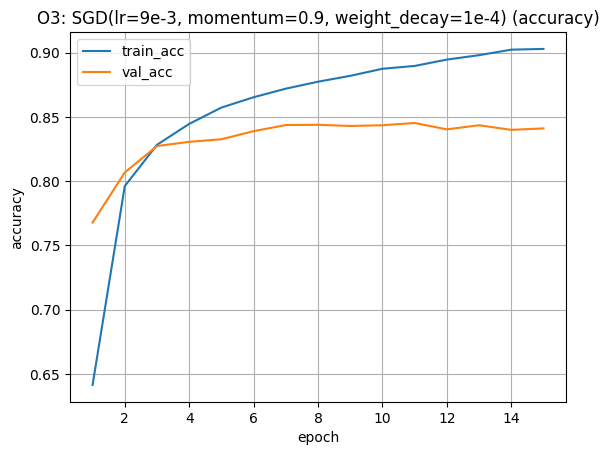

In [21]:
# O3: SGD + momentum + weight_decay
set_seed(42)
model_o3 = MLP(hidden_dims=(256, 128), dropout_p=dropout_e4, use_batchnorm=use_bn_e4,
               num_classes=len(class_names)).to(DEVICE)
optimizer_o3 = optim.SGD(model_o3.parameters(), lr=9e-3, momentum=0.9, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

history_o3 = fit(
    model_o3, train_loader, val_loader,
    optimizer_o3, criterion, DEVICE,
    epochs=15, early_stopping=EarlyStopping(patience=5)
)

best_val_acc_o3 = max(history_o3["val_acc"])
print(f"O3 best_val_acc = {best_val_acc_o3:.4f}")
plot_history(history_o3, title="O3: SGD(lr=9e-3, momentum=0.9, weight_decay=1e-4)")

In [22]:
# Таблица всех экспериментов
import pandas as pd

DATASET = "EMNIST-balanced"
runs_data = [
    {"experiment_id": "E1", "dataset": DATASET, "seed": RANDOM_STATE,
     "model_summary": "784->256->128->46/relu/no_dropout/no_bn",
     "optimizer": "Adam", "lr": 1e-3, "momentum": 0, "weight_decay": 0,
     "epochs_trained": len(history_e1["val_acc"]),
     "best_val_accuracy": round(best_val_acc_e1, 4),
     "best_val_loss": round(min(history_e1["val_loss"]), 4)},
    {"experiment_id": "E2", "dataset": DATASET, "seed": RANDOM_STATE,
     "model_summary": "784->256->128->46/relu/dropout=0.2/no_bn",
     "optimizer": "Adam", "lr": 1e-3, "momentum": 0, "weight_decay": 0,
     "epochs_trained": len(history_e2["val_acc"]),
     "best_val_accuracy": round(best_val_acc_e2, 4),
     "best_val_loss": round(min(history_e2["val_loss"]), 4)},
    {"experiment_id": "E3", "dataset": DATASET, "seed": RANDOM_STATE,
     "model_summary": "784->256->128->46/relu/no_dropout/bn",
     "optimizer": "Adam", "lr": 1e-3, "momentum": 0, "weight_decay": 0,
     "epochs_trained": len(history_e3["val_acc"]),
     "best_val_accuracy": round(best_val_acc_e3, 4),
     "best_val_loss": round(min(history_e3["val_loss"]), 4)},
    {"experiment_id": "E4", "dataset": DATASET, "seed": RANDOM_STATE,
     "model_summary": f"784->256->128->46/relu/dropout={dropout_e4}/bn={use_bn_e4}",
     "optimizer": "Adam", "lr": 1e-3, "momentum": 0, "weight_decay": 0,
     "epochs_trained": len(history_e4["val_acc"]),
     "best_val_accuracy": round(float(best_val_acc_e4), 4),
     "best_val_loss": round(min(history_e4["val_loss"]), 4)},
    {"experiment_id": "O1", "dataset": DATASET, "seed": RANDOM_STATE,
     "model_summary": f"784->256->128->46/relu/dropout={dropout_e4}/bn={use_bn_e4}",
     "optimizer": "Adam", "lr": 1.0, "momentum": 0, "weight_decay": 0,
     "epochs_trained": len(history_o1["val_acc"]),
     "best_val_accuracy": round(best_val_acc_o1, 4),
     "best_val_loss": round(min(history_o1["val_loss"]), 4)},
    {"experiment_id": "O2", "dataset": DATASET, "seed": RANDOM_STATE,
     "model_summary": f"784->256->128->46/relu/dropout={dropout_e4}/bn={use_bn_e4}",
     "optimizer": "Adam", "lr": 1e-10, "momentum": 0, "weight_decay": 0,
     "epochs_trained": len(history_o2["val_acc"]),
     "best_val_accuracy": round(best_val_acc_o2, 4),
     "best_val_loss": round(min(history_o2["val_loss"]), 4)},
    {"experiment_id": "O3", "dataset": DATASET, "seed": RANDOM_STATE,
     "model_summary": f"784->256->128->46/relu/dropout={dropout_e4}/bn={use_bn_e4}",
     "optimizer": "SGD", "lr": 9e-3, "momentum": 0.9, "weight_decay": 1e-4,
     "epochs_trained": len(history_o3["val_acc"]),
     "best_val_accuracy": round(best_val_acc_o3, 4),
     "best_val_loss": round(min(history_o3["val_loss"]), 4)},
]
df_runs = pd.DataFrame(runs_data)
df_runs.to_csv("artifacts/runs.csv", index=False)
print("Saved → artifacts/runs.csv")
df_runs

Saved → artifacts/runs.csv


,experiment_id,dataset,seed,model_summary,optimizer,lr,momentum,weight_decay,epochs_trained,best_val_accuracy,best_val_loss
0,E1,EMNIST-balanced,42,784->256->128->46/relu/no_dropout/no_bn,Adam,1.000000e-03,0.0,0.0000,20,0.8398,0.5052
1,E2,EMNIST-balanced,42,784->256->128->46/relu/dropout=0.2/no_bn,Adam,1.000000e-03,0.0,0.0000,20,0.8427,0.4745
2,E3,EMNIST-balanced,42,784->256->128->46/relu/no_dropout/bn,Adam,1.000000e-03,0.0,0.0000,20,0.8477,0.4691
3,E4,EMNIST-balanced,42,784->256->128->46/relu/dropout=0.0/bn=True,Adam,1.000000e-03,0.0,0.0000,12,0.8477,0.4691
4,O1,EMNIST-balanced,42,784->256->128->46/relu/dropout=0.0/bn=True,Adam,1.000000e+00,0.0,0.0000,8,0.1126,3.0905
5,O2,EMNIST-balanced,42,784->256->128->46/relu/dropout=0.0/bn=True,Adam,1.000000e-10,0.0,0.0000,8,0.0224,3.9420
6,O3,EMNIST-balanced,42,784->256->128->46/relu/dropout=0.0/bn=True,SGD,9.000000e-03,0.9,0.0001,15,0.8452,0.4666


# Проверка на test



In [23]:
# Финальная оценка лучшей модели на test (один раз)
model_test = MLP(hidden_dims=(256, 128), dropout_p=dropout_e4, use_batchnorm=use_bn_e4,
                 num_classes=len(class_names)).to(DEVICE)
state = torch.load(save_path, map_location=DEVICE)
model_test.load_state_dict(state)

test_loss, test_acc = evaluate(model_test, test_loader, criterion, DEVICE)
print(f"Test  loss = {test_loss:.4f}")
print(f"Test  acc  = {test_acc:.4f}")

/Users/hkvge/vscode/neuro_2/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Test  loss = 0.4840
Test  acc  = 0.8413
